# Phase 1: Data Generation & Least-Squares Baselines

This notebook does everything for Phase 1 in one place:

1. **Generate TEST trajectory** (seed=99) for original nonlinear springs — gives us unseen data for proper train/test evaluation
2. **Generate SHRUNK nonlinear spring data** (±0.25 soft region instead of ±1.0) — prof's suggestion, train + test
3. **Run Least-Squares system ID** on all variants and compute NSE (Normalized Simulation Error)
4. **Save D, E1, E2 matrices** for feeding to the RNN in Phase 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Make sure we save into the right folders
os.chdir(os.path.join(os.path.dirname(os.getcwd()), '') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd())
# Navigate to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\obedg\Downloads\RNN Honours Rotation


---
# Part 1: Generate TEST Trajectory for Original Nonlinear Springs

Same physics as `simulate_2_springs_simple.py` (seed=42), but with **seed=99** so the input force sequence is completely different. This is data the models have never seen during training.

In [2]:
# --- System Parameters (identical to training simulation) ---
m = np.array([1/4, 1/3])
c = np.array([1/4, 1/3])
k = np.array([1.0, 5/6])

# --- Original Nonlinear Spring Function (threshold = ±1.0) ---
def gamma_original(d):
    """Piecewise linear hardening spring from the paper. Soft (0.25) in |d|<1, stiff (1) outside."""
    if np.isscalar(d):
        if d <= -1: return d + 0.75
        elif d >= 1: return d - 0.75
        else: return 0.25 * d
    else:
        res = np.zeros_like(d)
        neg, pos = (d <= -1), (d >= 1)
        mid = (~neg) & (~pos)
        res[neg] = d[neg] + 0.75
        res[pos] = d[pos] - 0.75
        res[mid] = 0.25 * d[mid]
        return res

# --- RK4 solver ---
def rk4_step(func, t, y, dt, *args):
    k1 = func(t, y, *args)
    k2 = func(t + 0.5*dt, y + 0.5*dt*k1, *args)
    k3 = func(t + 0.5*dt, y + 0.5*dt*k2, *args)
    k4 = func(t + dt, y + dt*k3, *args)
    return y + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# --- Generic simulation runner ---
def run_simulation(gamma_func, seed, sigma_u=2.0):
    T_end = 200.0
    dt_sim = 0.01
    avg_switch_time = 5.0
    
    switch_times = np.arange(0, T_end + avg_switch_time, avg_switch_time)
    np.random.seed(seed)
    input_values = np.random.normal(0, sigma_u, len(switch_times))
    
    def get_u(t):
        idx = int(t // avg_switch_time)
        idx = np.clip(idx, 0, len(input_values) - 1)
        return input_values[idx]
    
    def dynamics(t, y):
        x1, v1, x2, v2 = y
        u = get_u(t)
        d1, d2 = x1, x2 - x1
        dv1, dv2 = v1, v2 - v1
        F_s1 = k[0] * gamma_func(d1)
        F_s2 = k[1] * gamma_func(d2)
        F_d1, F_d2 = c[0] * dv1, c[1] * dv2
        a1 = (u - F_s1 - F_d1 + F_s2 + F_d2) / m[0]
        a2 = (-F_s2 - F_d2) / m[1]
        return np.array([v1, a1, v2, a2])
    
    t_vals = np.arange(0, T_end, dt_sim)
    y_vals = np.zeros((len(t_vals), 4))
    for i in range(1, len(t_vals)):
        y_vals[i] = rk4_step(dynamics, t_vals[i-1], y_vals[i-1], dt_sim)
    
    u_plot = np.array([get_u(t) for t in t_vals])
    
    # Transformed coordinates
    z_vals = np.column_stack((
        y_vals[:, 0] - y_vals[:, 2],  # z1 = x1 - x2 (relative position)
        y_vals[:, 1] - y_vals[:, 3],  # z2 = v1 - v2 (relative velocity) 
        y_vals[:, 2],                  # z3 = x2 (abs position M2)
        y_vals[:, 3]                   # z4 = v2 (abs velocity M2)
    ))
    
    return t_vals, y_vals, u_plot, z_vals

print("Helper functions defined.")

Helper functions defined.


Generating TEST trajectory (seed=99, original springs ±1.0)...
Saved! Shape: (20000, 4)


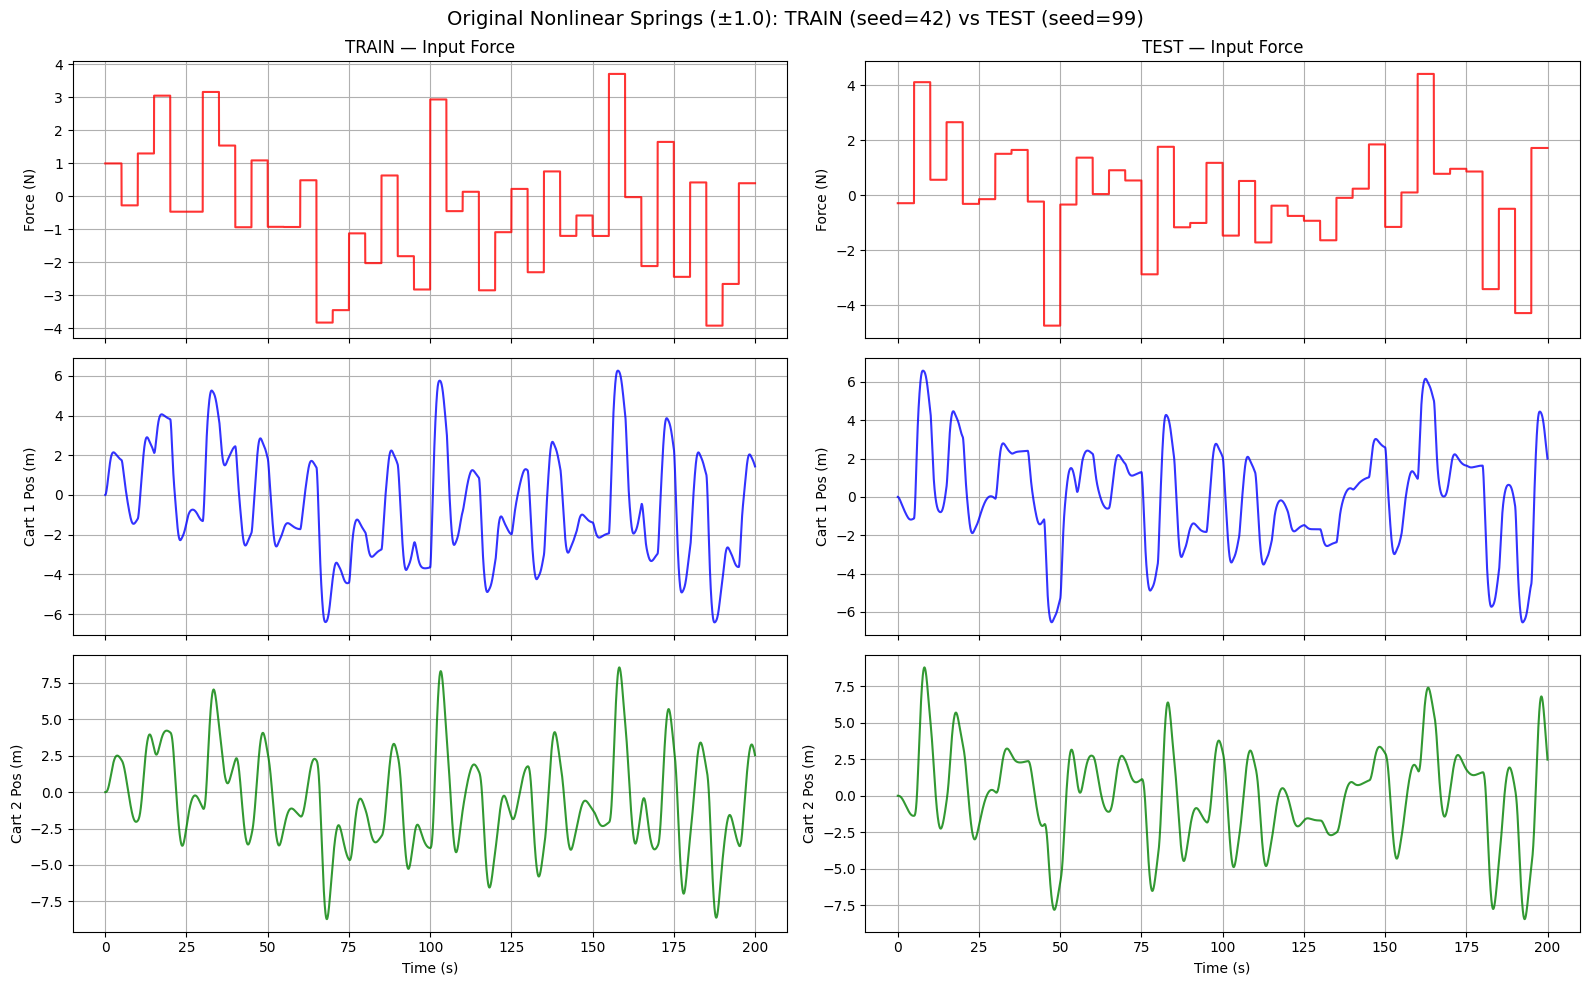

In [3]:
# Generate TEST trajectory for original nonlinear springs
print("Generating TEST trajectory (seed=99, original springs ±1.0)...")
t_vals, y_test_orig, u_test_orig, z_test_orig = run_simulation(gamma_original, seed=99)

np.savez("data/test_simulation_data.npz", y_vals=y_test_orig, u_plot=u_test_orig)
np.savez("data/test_transformed_simulation_data.npz", z_vals=z_test_orig, u_plot=u_test_orig)
print(f"Saved! Shape: {y_test_orig.shape}")

# Also load existing TRAIN data for comparison
train_data = np.load("data/simulation_data.npz")
y_train_orig = train_data['y_vals']
u_train_orig = np.array(train_data['u_plot'])
z_train_orig_data = np.load("data/transformed_simulation_data.npz")
z_train_orig = z_train_orig_data['z_vals']

# Plot: TRAIN vs TEST side by side
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex='col')
fig.suptitle("Original Nonlinear Springs (±1.0): TRAIN (seed=42) vs TEST (seed=99)", fontsize=14)

for col, (y, u, label) in enumerate([(y_train_orig, u_train_orig, "TRAIN"), 
                                       (y_test_orig, u_test_orig, "TEST")]):
    axes[0, col].plot(t_vals, u, 'r-', alpha=0.8)
    axes[0, col].set_title(f"{label} — Input Force")
    axes[0, col].set_ylabel("Force (N)")
    axes[0, col].grid(True)
    
    axes[1, col].plot(t_vals, y[:, 0], 'b-', alpha=0.8)
    axes[1, col].set_ylabel("Cart 1 Pos (m)")
    axes[1, col].grid(True)
    
    axes[2, col].plot(t_vals, y[:, 2], 'g-', alpha=0.8)
    axes[2, col].set_ylabel("Cart 2 Pos (m)")
    axes[2, col].set_xlabel("Time (s)")
    axes[2, col].grid(True)

plt.tight_layout()
plt.show()

---
# Part 2: Generate SHRUNK Nonlinear Spring Data (±0.25)

Prof's suggestion: shrink the soft region from ±1.0 to ±0.25. This means the spring transitions to the stiff regime at much smaller displacements, so the nonlinearity kicks in more often during typical motion.

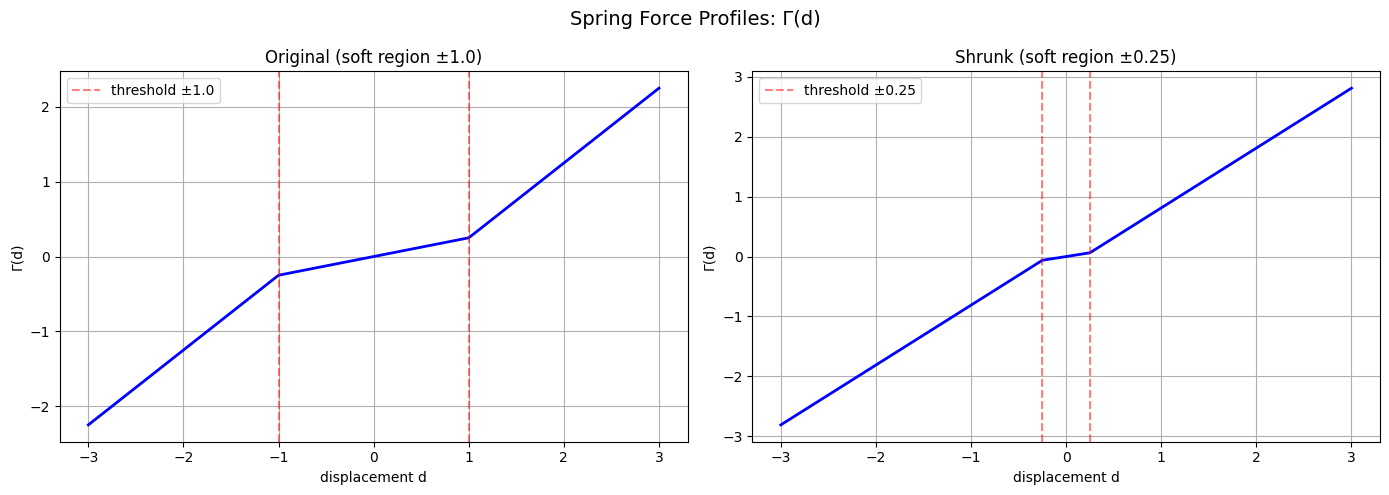

Key difference: with ±0.25, the spring hits the stiff linear regime at much smaller displacements.


In [4]:
# Visualize the two spring force profiles side by side
d_range = np.linspace(-3, 3, 500)

THRESHOLD = 0.25

def gamma_shrunk(d):
    """Shrunk nonlinear spring: soft region is now ±0.25 instead of ±1.0"""
    if np.isscalar(d):
        if d <= -THRESHOLD: return d + THRESHOLD * 0.75
        elif d >= THRESHOLD: return d - THRESHOLD * 0.75
        else: return 0.25 * d
    else:
        res = np.zeros_like(d)
        neg = d <= -THRESHOLD
        pos = d >= THRESHOLD
        mid = (~neg) & (~pos)
        res[neg] = d[neg] + THRESHOLD * 0.75
        res[pos] = d[pos] - THRESHOLD * 0.75
        res[mid] = 0.25 * d[mid]
        return res

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Spring Force Profiles: Γ(d)", fontsize=14)

axes[0].plot(d_range, gamma_original(d_range), 'b-', lw=2)
axes[0].axvline(-1, color='r', ls='--', alpha=0.5, label='threshold ±1.0')
axes[0].axvline(1, color='r', ls='--', alpha=0.5)
axes[0].set_title("Original (soft region ±1.0)")
axes[0].set_xlabel("displacement d")
axes[0].set_ylabel("Γ(d)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(d_range, gamma_shrunk(d_range), 'b-', lw=2)
axes[1].axvline(-THRESHOLD, color='r', ls='--', alpha=0.5, label=f'threshold ±{THRESHOLD}')
axes[1].axvline(THRESHOLD, color='r', ls='--', alpha=0.5)
axes[1].set_title(f"Shrunk (soft region ±{THRESHOLD})")
axes[1].set_xlabel("displacement d")
axes[1].set_ylabel("Γ(d)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Key difference: with ±0.25, the spring hits the stiff linear regime at much smaller displacements.")

Generating TRAIN trajectory (seed=42, shrunk springs ±0.25)...
Generating TEST trajectory (seed=99, shrunk springs ±0.25)...
All shrunk data saved!


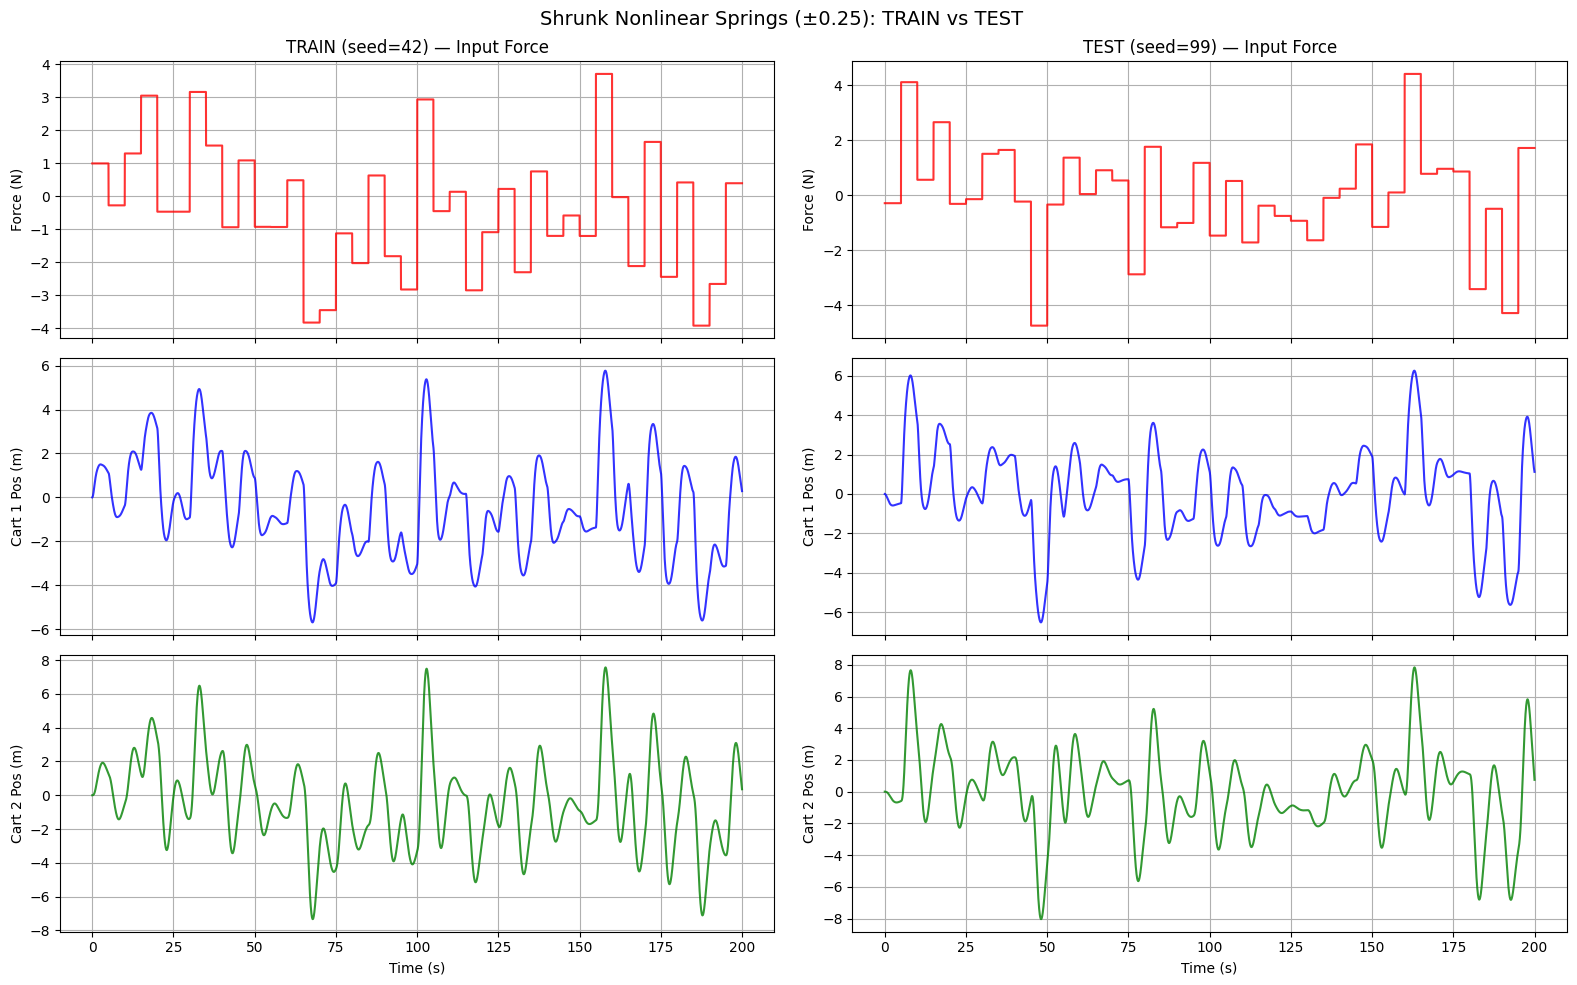

In [5]:
# Generate TRAIN and TEST for shrunk springs
print("Generating TRAIN trajectory (seed=42, shrunk springs ±0.25)...")
t_vals, y_train_shrunk, u_train_shrunk, z_train_shrunk = run_simulation(gamma_shrunk, seed=42)

print("Generating TEST trajectory (seed=99, shrunk springs ±0.25)...")
_, y_test_shrunk, u_test_shrunk, z_test_shrunk = run_simulation(gamma_shrunk, seed=99)

# Save all
np.savez("data/shrunk_train_simulation_data.npz", y_vals=y_train_shrunk, u_plot=u_train_shrunk)
np.savez("data/shrunk_train_transformed_data.npz", z_vals=z_train_shrunk, u_plot=u_train_shrunk)
np.savez("data/shrunk_test_simulation_data.npz", y_vals=y_test_shrunk, u_plot=u_test_shrunk)
np.savez("data/shrunk_test_transformed_data.npz", z_vals=z_test_shrunk, u_plot=u_test_shrunk)
print("All shrunk data saved!")

# Plot
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex='col')
fig.suptitle("Shrunk Nonlinear Springs (±0.25): TRAIN vs TEST", fontsize=14)

for col, (y, u, label) in enumerate([(y_train_shrunk, u_train_shrunk, "TRAIN (seed=42)"), 
                                       (y_test_shrunk, u_test_shrunk, "TEST (seed=99)")]):
    axes[0, col].plot(t_vals, u, 'r-', alpha=0.8)
    axes[0, col].set_title(f"{label} — Input Force")
    axes[0, col].set_ylabel("Force (N)")
    axes[0, col].grid(True)
    
    axes[1, col].plot(t_vals, y[:, 0], 'b-', alpha=0.8)
    axes[1, col].set_ylabel("Cart 1 Pos (m)")
    axes[1, col].grid(True)
    
    axes[2, col].plot(t_vals, y[:, 2], 'g-', alpha=0.8)
    axes[2, col].set_ylabel("Cart 2 Pos (m)")
    axes[2, col].set_xlabel("Time (s)")
    axes[2, col].grid(True)

plt.tight_layout()
plt.show()

---
# Part 3: Least-Squares System Identification on All Variants

We fit the ARMA model: $x_{k+1} = D \cdot x_k + E_1 \cdot u_{k+1} + E_2 \cdot u_k$

For each variant we:
1. Fit D, E1, E2 on **training** data
2. Autoregressive rollout on **training** data (sanity check)
3. Autoregressive rollout on **test** data (real evaluation)
4. Compute NSE = $\frac{\|\tilde{y} - y\|}{\|\tilde{y}\|}$ (the paper's metric)

In [6]:
def compute_nse(y_true, y_pred):
    """Normalized Simulation Error = ||y_true - y_pred|| / ||y_true||"""
    return np.linalg.norm(y_true - y_pred) / (np.linalg.norm(y_true) + 1e-10)

def fit_ls_model(y_vals, u_plot):
    """Fit x_{k+1} = D*x_k + E1*u_{k+1} + E2*u_k via pseudoinverse"""
    X_curr = y_vals[:-1, :].T
    X_next = y_vals[1:, :].T
    U_curr = u_plot[:-1].reshape(1, -1)
    U_next = u_plot[1:].reshape(1, -1)
    Z = np.vstack((X_curr, U_next, U_curr))
    theta = X_next @ Z.T @ np.linalg.pinv(Z @ Z.T)
    return theta[:, :4], theta[:, 4:5], theta[:, 5:6]  # D, E1, E2

def rollout_ls(D, E1, E2, y0, u_plot, N):
    """Autoregressive rollout of LS model"""
    y_pred = np.zeros((N, 4))
    y_pred[0] = y0
    for k in range(N - 1):
        x_k = y_pred[k].reshape(4, 1)
        u_k_next = u_plot[k + 1] if k + 1 < N else u_plot[k]
        y_pred[k + 1] = (D @ x_k + E1 * u_k_next + E2 * u_plot[k]).flatten()
    return y_pred

print("LS helper functions defined.")

LS helper functions defined.


## 3a. LS on Original Nonlinear Springs (raw states)

Original Nonlinear (raw) — TRAIN NSE: Cart1=0.1560, Cart2=0.1827
Original Nonlinear (raw) — TEST  NSE: Cart1=0.1844, Cart2=0.2158


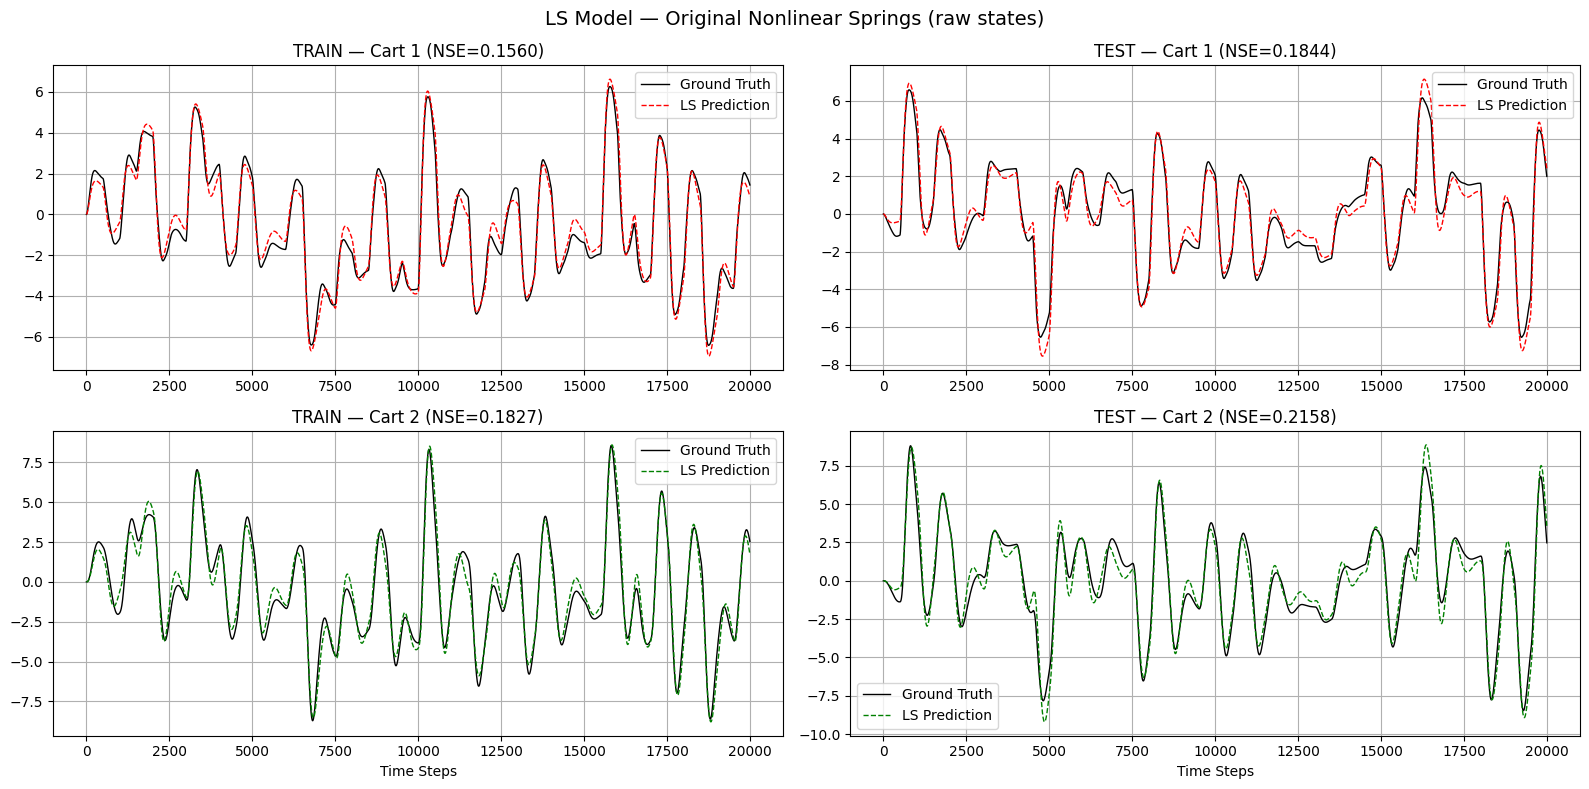

In [7]:
# Fit on training data
D_orig, E1_orig, E2_orig = fit_ls_model(y_train_orig, u_train_orig)
np.savez("data/ls_matrices_original_raw.npz", D=D_orig, E1=E1_orig, E2=E2_orig)

# Rollout on TRAIN
y_pred_train = rollout_ls(D_orig, E1_orig, E2_orig, y_train_orig[0], u_train_orig, len(u_train_orig))

# Rollout on TEST
y_pred_test = rollout_ls(D_orig, E1_orig, E2_orig, y_test_orig[0], u_test_orig, len(u_test_orig))

# NSE
nse_train_c1 = compute_nse(y_train_orig[:, 0], y_pred_train[:, 0])
nse_train_c2 = compute_nse(y_train_orig[:, 2], y_pred_train[:, 2])
nse_test_c1 = compute_nse(y_test_orig[:, 0], y_pred_test[:, 0])
nse_test_c2 = compute_nse(y_test_orig[:, 2], y_pred_test[:, 2])

print(f"Original Nonlinear (raw) — TRAIN NSE: Cart1={nse_train_c1:.4f}, Cart2={nse_train_c2:.4f}")
print(f"Original Nonlinear (raw) — TEST  NSE: Cart1={nse_test_c1:.4f}, Cart2={nse_test_c2:.4f}")

# Plot: Train on left, Test on right
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("LS Model — Original Nonlinear Springs (raw states)", fontsize=14)

axes[0,0].plot(y_train_orig[:, 0], 'k-', lw=1, label='Ground Truth')
axes[0,0].plot(y_pred_train[:, 0], 'r--', lw=1, label='LS Prediction')
axes[0,0].set_title(f"TRAIN — Cart 1 (NSE={nse_train_c1:.4f})")
axes[0,0].legend(); axes[0,0].grid(True)

axes[1,0].plot(y_train_orig[:, 2], 'k-', lw=1, label='Ground Truth')
axes[1,0].plot(y_pred_train[:, 2], 'g--', lw=1, label='LS Prediction')
axes[1,0].set_title(f"TRAIN — Cart 2 (NSE={nse_train_c2:.4f})")
axes[1,0].legend(); axes[1,0].grid(True); axes[1,0].set_xlabel('Time Steps')

axes[0,1].plot(y_test_orig[:, 0], 'k-', lw=1, label='Ground Truth')
axes[0,1].plot(y_pred_test[:, 0], 'r--', lw=1, label='LS Prediction')
axes[0,1].set_title(f"TEST — Cart 1 (NSE={nse_test_c1:.4f})")
axes[0,1].legend(); axes[0,1].grid(True)

axes[1,1].plot(y_test_orig[:, 2], 'k-', lw=1, label='Ground Truth')
axes[1,1].plot(y_pred_test[:, 2], 'g--', lw=1, label='LS Prediction')
axes[1,1].set_title(f"TEST — Cart 2 (NSE={nse_test_c2:.4f})")
axes[1,1].legend(); axes[1,1].grid(True); axes[1,1].set_xlabel('Time Steps')

plt.tight_layout()
plt.show()

## 3b. LS on Original Nonlinear Springs (transformed z-coordinates)

Original Nonlinear (transformed) — TRAIN NSE: z1=0.3280, z3=0.1827
Original Nonlinear (transformed) — TEST  NSE: z1=0.4021, z3=0.2158


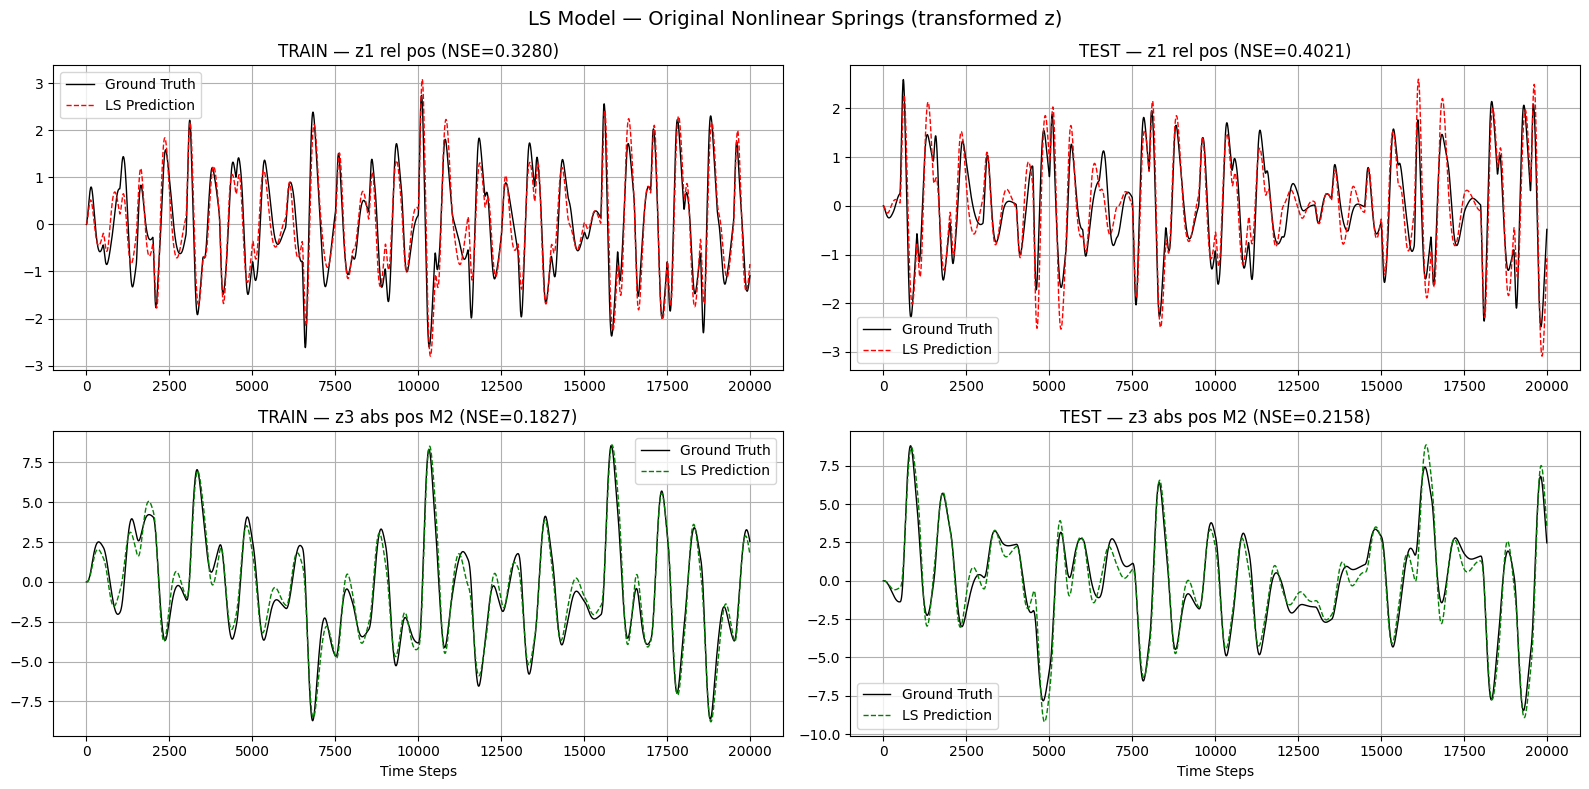

In [8]:
# Fit on transformed training data
D_orig_t, E1_orig_t, E2_orig_t = fit_ls_model(z_train_orig, u_train_orig)
np.savez("data/ls_matrices_original_transformed.npz", D=D_orig_t, E1=E1_orig_t, E2=E2_orig_t)

# Rollout
z_pred_train = rollout_ls(D_orig_t, E1_orig_t, E2_orig_t, z_train_orig[0], u_train_orig, len(u_train_orig))
z_pred_test = rollout_ls(D_orig_t, E1_orig_t, E2_orig_t, z_test_orig[0], u_test_orig, len(u_test_orig))

# NSE
nse_tr_z1 = compute_nse(z_train_orig[:, 0], z_pred_train[:, 0])
nse_tr_z3 = compute_nse(z_train_orig[:, 2], z_pred_train[:, 2])
nse_te_z1 = compute_nse(z_test_orig[:, 0], z_pred_test[:, 0])
nse_te_z3 = compute_nse(z_test_orig[:, 2], z_pred_test[:, 2])

print(f"Original Nonlinear (transformed) — TRAIN NSE: z1={nse_tr_z1:.4f}, z3={nse_tr_z3:.4f}")
print(f"Original Nonlinear (transformed) — TEST  NSE: z1={nse_te_z1:.4f}, z3={nse_te_z3:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("LS Model — Original Nonlinear Springs (transformed z)", fontsize=14)

axes[0,0].plot(z_train_orig[:, 0], 'k-', lw=1, label='Ground Truth')
axes[0,0].plot(z_pred_train[:, 0], 'r--', lw=1, label='LS Prediction')
axes[0,0].set_title(f"TRAIN — z1 rel pos (NSE={nse_tr_z1:.4f})")
axes[0,0].legend(); axes[0,0].grid(True)

axes[1,0].plot(z_train_orig[:, 2], 'k-', lw=1, label='Ground Truth')
axes[1,0].plot(z_pred_train[:, 2], 'g--', lw=1, label='LS Prediction')
axes[1,0].set_title(f"TRAIN — z3 abs pos M2 (NSE={nse_tr_z3:.4f})")
axes[1,0].legend(); axes[1,0].grid(True); axes[1,0].set_xlabel('Time Steps')

axes[0,1].plot(z_test_orig[:, 0], 'k-', lw=1, label='Ground Truth')
axes[0,1].plot(z_pred_test[:, 0], 'r--', lw=1, label='LS Prediction')
axes[0,1].set_title(f"TEST — z1 rel pos (NSE={nse_te_z1:.4f})")
axes[0,1].legend(); axes[0,1].grid(True)

axes[1,1].plot(z_test_orig[:, 2], 'k-', lw=1, label='Ground Truth')
axes[1,1].plot(z_pred_test[:, 2], 'g--', lw=1, label='LS Prediction')
axes[1,1].set_title(f"TEST — z3 abs pos M2 (NSE={nse_te_z3:.4f})")
axes[1,1].legend(); axes[1,1].grid(True); axes[1,1].set_xlabel('Time Steps')

plt.tight_layout()
plt.show()

## 3c. LS on Shrunk Nonlinear Springs ±0.25 (raw states)

Shrunk ±0.25 (raw) — TRAIN NSE: Cart1=0.0535, Cart2=0.0727
Shrunk ±0.25 (raw) — TEST  NSE: Cart1=0.0652, Cart2=0.0938


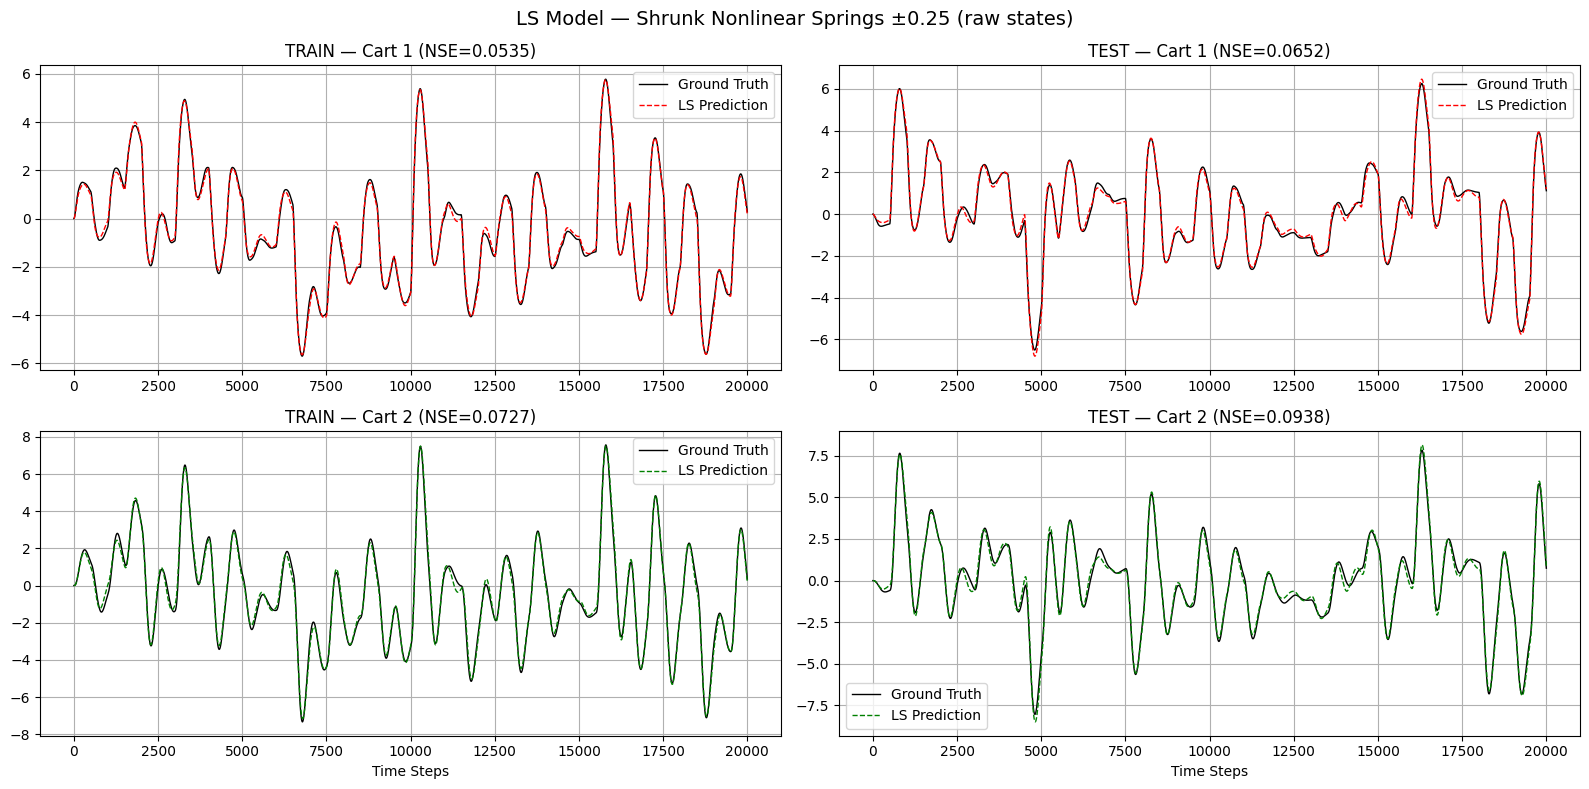

In [9]:
# Fit on shrunk training data (raw states)
D_shrunk, E1_shrunk, E2_shrunk = fit_ls_model(y_train_shrunk, u_train_shrunk)
np.savez("data/ls_matrices_shrunk_raw.npz", D=D_shrunk, E1=E1_shrunk, E2=E2_shrunk)

# Rollout
y_pred_train_s = rollout_ls(D_shrunk, E1_shrunk, E2_shrunk, y_train_shrunk[0], u_train_shrunk, len(u_train_shrunk))
y_pred_test_s = rollout_ls(D_shrunk, E1_shrunk, E2_shrunk, y_test_shrunk[0], u_test_shrunk, len(u_test_shrunk))

# NSE
nse_str_c1 = compute_nse(y_train_shrunk[:, 0], y_pred_train_s[:, 0])
nse_str_c2 = compute_nse(y_train_shrunk[:, 2], y_pred_train_s[:, 2])
nse_ste_c1 = compute_nse(y_test_shrunk[:, 0], y_pred_test_s[:, 0])
nse_ste_c2 = compute_nse(y_test_shrunk[:, 2], y_pred_test_s[:, 2])

print(f"Shrunk ±0.25 (raw) — TRAIN NSE: Cart1={nse_str_c1:.4f}, Cart2={nse_str_c2:.4f}")
print(f"Shrunk ±0.25 (raw) — TEST  NSE: Cart1={nse_ste_c1:.4f}, Cart2={nse_ste_c2:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("LS Model — Shrunk Nonlinear Springs ±0.25 (raw states)", fontsize=14)

axes[0,0].plot(y_train_shrunk[:, 0], 'k-', lw=1, label='Ground Truth')
axes[0,0].plot(y_pred_train_s[:, 0], 'r--', lw=1, label='LS Prediction')
axes[0,0].set_title(f"TRAIN — Cart 1 (NSE={nse_str_c1:.4f})")
axes[0,0].legend(); axes[0,0].grid(True)

axes[1,0].plot(y_train_shrunk[:, 2], 'k-', lw=1, label='Ground Truth')
axes[1,0].plot(y_pred_train_s[:, 2], 'g--', lw=1, label='LS Prediction')
axes[1,0].set_title(f"TRAIN — Cart 2 (NSE={nse_str_c2:.4f})")
axes[1,0].legend(); axes[1,0].grid(True); axes[1,0].set_xlabel('Time Steps')

axes[0,1].plot(y_test_shrunk[:, 0], 'k-', lw=1, label='Ground Truth')
axes[0,1].plot(y_pred_test_s[:, 0], 'r--', lw=1, label='LS Prediction')
axes[0,1].set_title(f"TEST — Cart 1 (NSE={nse_ste_c1:.4f})")
axes[0,1].legend(); axes[0,1].grid(True)

axes[1,1].plot(y_test_shrunk[:, 2], 'k-', lw=1, label='Ground Truth')
axes[1,1].plot(y_pred_test_s[:, 2], 'g--', lw=1, label='LS Prediction')
axes[1,1].set_title(f"TEST — Cart 2 (NSE={nse_ste_c2:.4f})")
axes[1,1].legend(); axes[1,1].grid(True); axes[1,1].set_xlabel('Time Steps')

plt.tight_layout()
plt.show()

## 3d. LS on Shrunk Nonlinear Springs ±0.25 (transformed z-coordinates)

Shrunk ±0.25 (transformed) — TRAIN NSE: z1=0.1636, z3=0.0727
Shrunk ±0.25 (transformed) — TEST  NSE: z1=0.2145, z3=0.0938


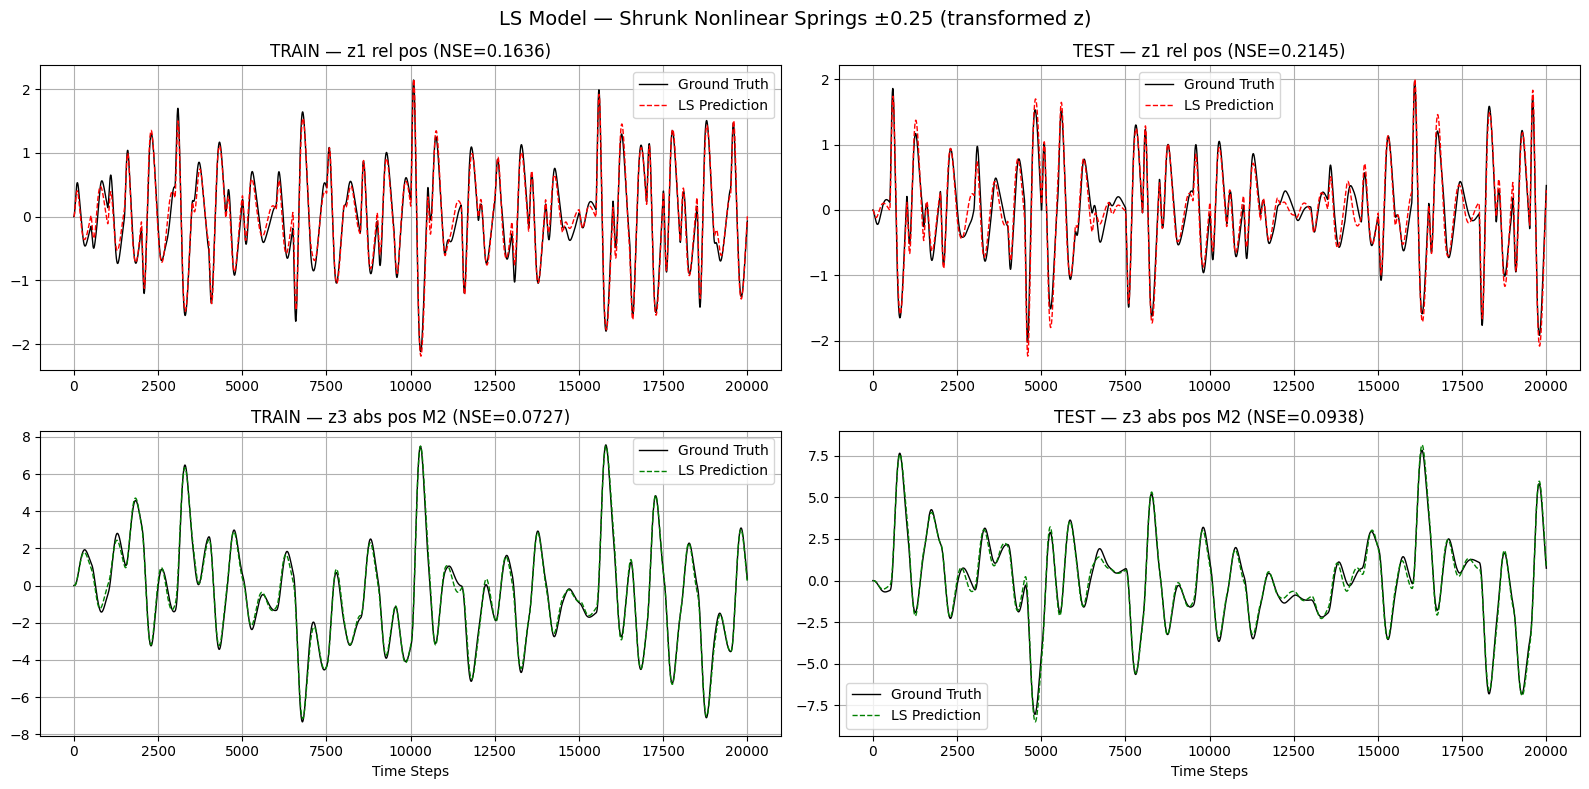

In [10]:
# Fit on shrunk transformed training data
D_shrunk_t, E1_shrunk_t, E2_shrunk_t = fit_ls_model(z_train_shrunk, u_train_shrunk)
np.savez("data/ls_matrices_shrunk_transformed.npz", D=D_shrunk_t, E1=E1_shrunk_t, E2=E2_shrunk_t)

# Rollout
z_pred_train_s = rollout_ls(D_shrunk_t, E1_shrunk_t, E2_shrunk_t, z_train_shrunk[0], u_train_shrunk, len(u_train_shrunk))
z_pred_test_s = rollout_ls(D_shrunk_t, E1_shrunk_t, E2_shrunk_t, z_test_shrunk[0], u_test_shrunk, len(u_test_shrunk))

# NSE
nse_str_z1 = compute_nse(z_train_shrunk[:, 0], z_pred_train_s[:, 0])
nse_str_z3 = compute_nse(z_train_shrunk[:, 2], z_pred_train_s[:, 2])
nse_ste_z1 = compute_nse(z_test_shrunk[:, 0], z_pred_test_s[:, 0])
nse_ste_z3 = compute_nse(z_test_shrunk[:, 2], z_pred_test_s[:, 2])

print(f"Shrunk ±0.25 (transformed) — TRAIN NSE: z1={nse_str_z1:.4f}, z3={nse_str_z3:.4f}")
print(f"Shrunk ±0.25 (transformed) — TEST  NSE: z1={nse_ste_z1:.4f}, z3={nse_ste_z3:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("LS Model — Shrunk Nonlinear Springs ±0.25 (transformed z)", fontsize=14)

axes[0,0].plot(z_train_shrunk[:, 0], 'k-', lw=1, label='Ground Truth')
axes[0,0].plot(z_pred_train_s[:, 0], 'r--', lw=1, label='LS Prediction')
axes[0,0].set_title(f"TRAIN — z1 rel pos (NSE={nse_str_z1:.4f})")
axes[0,0].legend(); axes[0,0].grid(True)

axes[1,0].plot(z_train_shrunk[:, 2], 'k-', lw=1, label='Ground Truth')
axes[1,0].plot(z_pred_train_s[:, 2], 'g--', lw=1, label='LS Prediction')
axes[1,0].set_title(f"TRAIN — z3 abs pos M2 (NSE={nse_str_z3:.4f})")
axes[1,0].legend(); axes[1,0].grid(True); axes[1,0].set_xlabel('Time Steps')

axes[0,1].plot(z_test_shrunk[:, 0], 'k-', lw=1, label='Ground Truth')
axes[0,1].plot(z_pred_test_s[:, 0], 'r--', lw=1, label='LS Prediction')
axes[0,1].set_title(f"TEST — z1 rel pos (NSE={nse_ste_z1:.4f})")
axes[0,1].legend(); axes[0,1].grid(True)

axes[1,1].plot(z_test_shrunk[:, 2], 'k-', lw=1, label='Ground Truth')
axes[1,1].plot(z_pred_test_s[:, 2], 'g--', lw=1, label='LS Prediction')
axes[1,1].set_title(f"TEST — z3 abs pos M2 (NSE={nse_ste_z3:.4f})")
axes[1,1].legend(); axes[1,1].grid(True); axes[1,1].set_xlabel('Time Steps')

plt.tight_layout()
plt.show()

---
# Summary: LS Baseline NSE Across All Variants

Lower NSE = better. These are the numbers to beat with the RNN in Phase 2.

**Key observation:** The shrunk springs (±0.25) give *lower* NSE because the system spends most of its time in the stiff linear regime (slope=1), making the linear LS model a better fit. The original springs (±1.0) spend more time in the soft nonlinear region, which the linear model can't capture.

In [16]:
# Summary table of all NSE results
print("Summary of Least-Squares Normalized Simulation Error (NSE)")
print(f"\n{'Variant':<40} {'Train NSE (avg)':>14} {'Test NSE (avg)':>14}")

results_summary = {
    'Original ±1.0 (raw states)':       ((nse_train_c1 + nse_train_c2)/2, (nse_test_c1 + nse_test_c2)/2),
    'Original ±1.0 (transformed z)':    ((nse_tr_z1 + nse_tr_z3)/2, (nse_te_z1 + nse_te_z3)/2),
    'Shrunk ±0.25 (raw states)':        ((nse_str_c1 + nse_str_c2)/2, (nse_ste_c1 + nse_ste_c2)/2),
    'Shrunk ±0.25 (transformed z)':     ((nse_str_z1 + nse_str_z3)/2, (nse_ste_z1 + nse_ste_z3)/2),
}

for name, (train_nse, test_nse) in results_summary.items():
    print(f"{name:<40} {train_nse:>14.4f} {test_nse:>14.4f}")

print("\nD, E1, E2 matrices saved to data/ls_matrices_*.npz for Phase 2 RNN experiments.")
print("Phase 1 complete!")

Summary of Least-Squares Normalized Simulation Error (NSE)

Variant                                  Train NSE (avg) Test NSE (avg)
Original ±1.0 (raw states)                       0.1693         0.2001
Original ±1.0 (transformed z)                    0.2553         0.3089
Shrunk ±0.25 (raw states)                        0.0631         0.0795
Shrunk ±0.25 (transformed z)                     0.1181         0.1542

D, E1, E2 matrices saved to data/ls_matrices_*.npz for Phase 2 RNN experiments.
Phase 1 complete!
